# 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 2. Dataset load from Hugging face

In [2]:
from datasets import load_dataset

In [3]:
 emotion_dataset = load_dataset('dair-ai/emotion')

In [4]:

emotion_dataset  

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [5]:
# For training Data
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']

# For testing Data
test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [6]:
label_names = emotion_dataset['train'].features['label'].names

In [7]:
# Mapping
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [8]:
df_train = pd.DataFrame({
    'text': train_text,
    'label':[label_names[i] for i in train_label]
})


df_test = pd.DataFrame({
    'text': test_text,
    'label':[label_names[i] for i in test_label]
})

In [9]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [10]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

# 3. Exploratory Data Analysis (EDA)

In [11]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

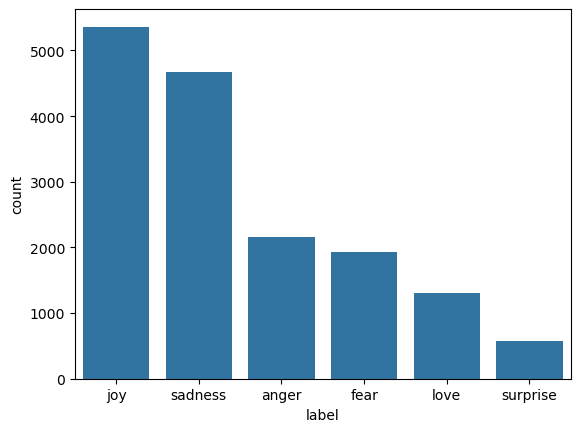

In [12]:
sns.countplot(x='label', data=df_train, order = df_train['label'].value_counts().index)

# 4. Data Preprocessing- Using NLP

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences 

max_words = 10000

tokenizer = Tokenizer(num_words = max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence, maxlen=50, padding='post',truncating='post')
padded_test_sequence = pad_sequences(test_sequence, maxlen=50, padding='post',truncating='post')

train_labels = np.array(train_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_label))
num_classes

print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")


Vocabulary Size: 15213
Max Sentence Length: 50


# 5. Shared Training Utilities

In [14]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)
class_weight_dict = dict(enumerate(class_weights))


In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience = 3,
    restore_best_weights=True
)

# 6. Foundational Models

In [16]:
# Model 1 = Simple RNN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM,GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') # Output Layer
])

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [17]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    validation_split = 0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Lose: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.1636 - loss: 2.0063 - val_accuracy: 0.0845 - val_loss: 1.8478
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.1504 - loss: 1.8912 - val_accuracy: 0.3345 - val_loss: 1.7386
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.1393 - loss: 1.8276 - val_accuracy: 0.0420 - val_loss: 1.8328
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1382 - loss: 1.8089 - val_accuracy: 0.1110 - val_loss: 1.7809
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.1481 - loss: 1.8000 - val_accuracy: 0.0885 - val_loss: 1.8293
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3345 - loss: 1.7386
RNN Lose: 1.7386128902435303
RNN Accuracy: 0.3345000147819519


In [18]:
# Model2 -Standar LSTM

lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') # Output Layer
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [19]:
lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    validation_split = 0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Lose: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.1372 - loss: 1.7944 - val_accuracy: 0.0795 - val_loss: 1.8289
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.1388 - loss: 1.7949 - val_accuracy: 0.1410 - val_loss: 1.7845
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.1558 - loss: 1.7926 - val_accuracy: 0.3165 - val_loss: 1.7797
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.1707 - loss: 1.7745 - val_accuracy: 0.1420 - val_loss: 1.7717
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.2180 - loss: 1.6608 - val_accuracy: 0.2855 - val_loss: 1.6456
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.3689 - loss: 1.3756 - val_accuracy: 0.4285 - val_loss: 1.4232
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.5963 - loss: 0.9204 - val_accuracy: 0.6080 - val_loss: 0.9904
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.7699 - loss: 0.6029 - 

In [20]:
# Model3 = Standard GRU

gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128, input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') # Output Layer
])

gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [21]:
gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size = 32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Lose: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 27ms/step - accuracy: 0.1649 - loss: 1.7966 - val_accuracy: 0.0335 - val_loss: 1.7978
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1386 - loss: 1.7960 - val_accuracy: 0.2900 - val_loss: 1.7802
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1688 - loss: 1.7943 - val_accuracy: 0.1365 - val_loss: 1.8031
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.1536 - loss: 1.7936 - val_accuracy: 0.0340 - val_loss: 1.8031
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1666 - loss: 1.7892 - val_accuracy: 0.3090 - val_loss: 1.7779
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - accuracy: 0.1849 - loss: 1.7645 - val_accuracy: 0.1410 - val_loss: 1.8099
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.2148 - loss: 1.7193 - val_accuracy: 0.0760 - val_loss: 1.8513
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.2494 - loss: 1.6310 - 

In [22]:
# Phase1: Raking & Selection

result_df = pd.DataFrame({
    'Model' : ['RNN','LSTM','GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy':[rnn_accuracy,lstm_accuracy,gru_accuracy]
}).sort_values(by='Test Accuracy',ascending=False)

In [23]:
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,0.368737,0.8825
0,RNN,1.738613,0.3345
2,GRU,1.777864,0.3090


In [24]:
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dropout, Dense, Input


BiGRU = Sequential([
    Input(shape=(50,)), 
    Embedding(input_dim=max_words, output_dim=300),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])


BiGRU.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'] 
)

BiGRU.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)              │ (None, 50, 300)             │       3,000,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 50, 256)             │         330,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 50, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │         123,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,454,662 (13.18 MB)

 Trainable params: 3,454,662 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
BiGRU.fit( 
    padded_train_sequence, train_labels,
    validation_data=(padded_test_sequence,test_labels),
    epochs=20, batch_size=32,
    class_weight=class_weight_dict, callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.5792 - loss: 1.0054 - val_accuracy: 0.8905 - val_loss: 0.3581
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.9189 - loss: 0.2373 - val_accuracy: 0.9075 - val_loss: 0.2572
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.9436 - loss: 0.1492 - val_accuracy: 0.9165 - val_loss: 0.2309
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 51ms/step - accuracy: 0.9576 - loss: 0.1139 - val_accuracy: 0.9140 - val_loss: 0.2761
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 51ms/step - accuracy: 0.9684 - loss: 0.0880 - val_accuracy: 0.9215 - val_loss: 0.2221
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 50ms/step - accuracy: 0.9750 - loss: 0.0711 - val_accuracy: 0.9270 - val_loss: 0.2331
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.9814 - loss: 0.0529 - val_accuracy: 0.9235 - val_loss: 0.2489
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.9832 - loss: 0.0517 - 

In [26]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9215 - loss: 0.2221
BiGRU Loss: 0.2220681607723236
BiGRU Accuracy: 0.921500027179718


# 7. Overall Evaluation & Bias Analysis

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


<Axes: >

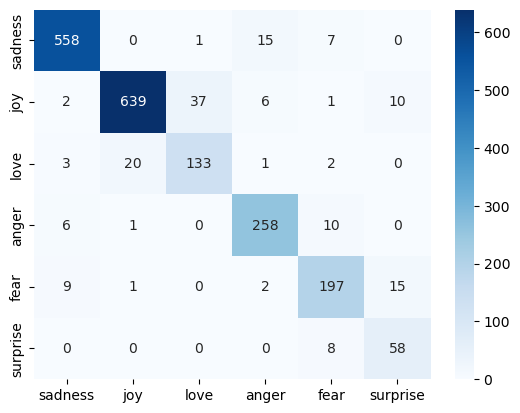

In [30]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence), axis=1)

sns.heatmap(
    confusion_matrix(test_label, BiGRU_predictions),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names,  
)


# 8. Final Predictions

In [31]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences,maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences),axis=1)
sample_predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


array([5, 0, 3, 4, 5])

In [32]:
for i in range(len(sample_texts)):
    print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


# 9. Save the Model & Tokenizer

In [33]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

In [36]:
# Save the tokenizer model
BiGRU.save(os.path.join(model_dir,'BiGRU_Modle.keras'))

In [37]:
# Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'),'wb') as file:
    pickle.dump(tokenizer, file)